In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [157]:
df = pd.read_csv('data.csv')

In [158]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## EDA


In [159]:
df.shape

(10000, 14)

In [160]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [161]:
df = df.drop(['RowNumber', 'Surname', 'CustomerId'], axis=1)

In [162]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [163]:
df['Gender'] = (df['Gender']=="Female").astype(int)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,1,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,1,41,1,83807.86,1,0,1,112542.58,0
2,502,France,1,42,8,159660.80,3,1,0,113931.57,1
3,699,France,1,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,1,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,0,39,5,0.00,2,1,0,96270.64,0
9996,516,France,0,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,1,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,0,42,3,75075.31,2,1,0,92888.52,1


In [164]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=False)

In [165]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,1,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [166]:
df['Geography_France'] = (df['Geography_France']==True).astype(int)
df['Geography_Germany'] = (df['Geography_Germany']==True).astype(int)
df['Geography_Spain'] = (df['Geography_Spain']==True).astype(int)


In [167]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,0,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,1,36,7,0.00,1,0,1,42085.58,1,1,0,0
9998,772,0,42,3,75075.31,2,1,0,92888.52,1,0,1,0


In [168]:
df.dtypes

,0
CreditScore,int64
Gender,int64
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64
Exited,int64


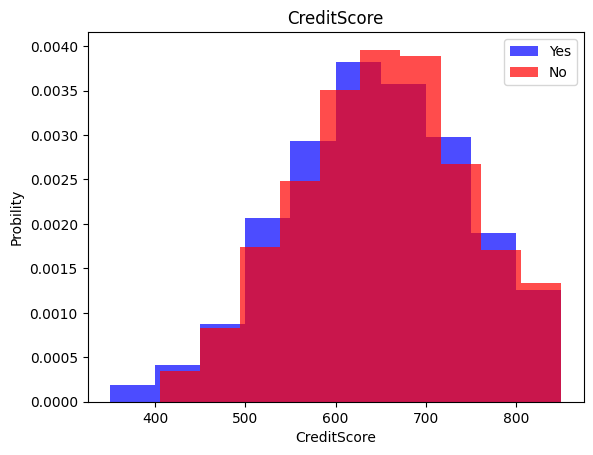

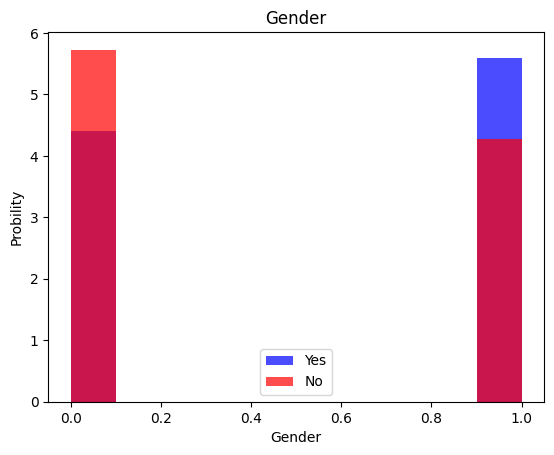

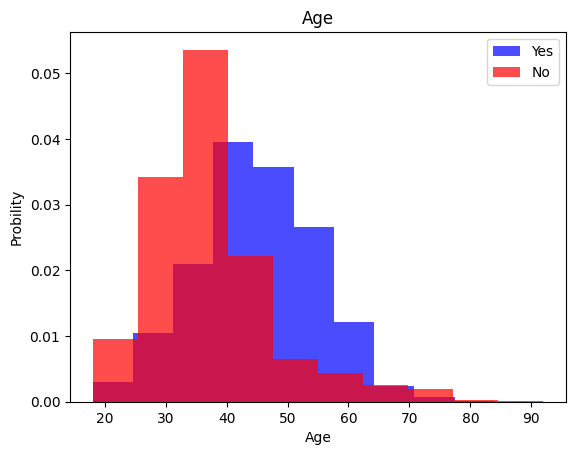

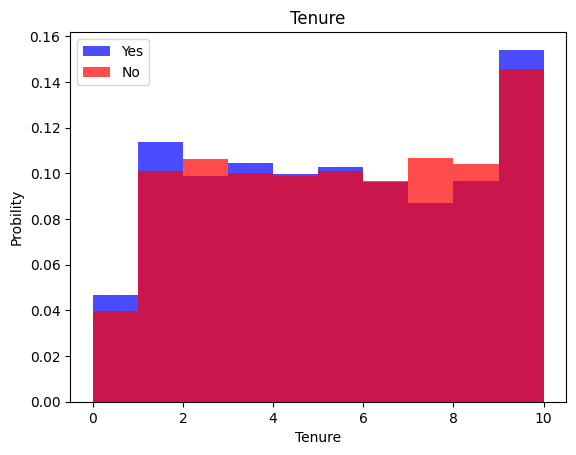

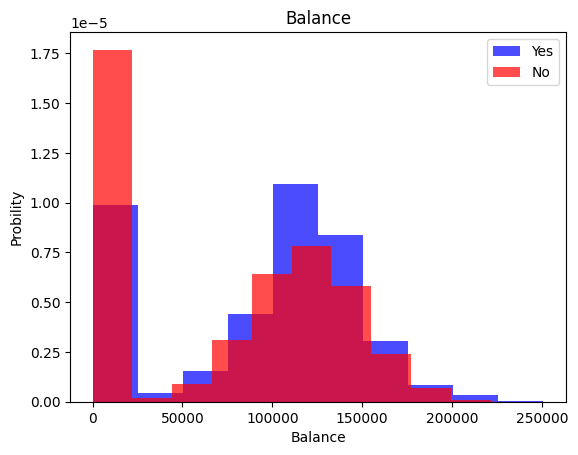

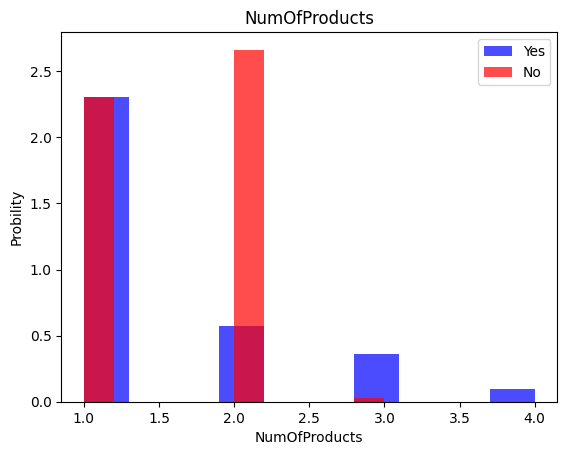

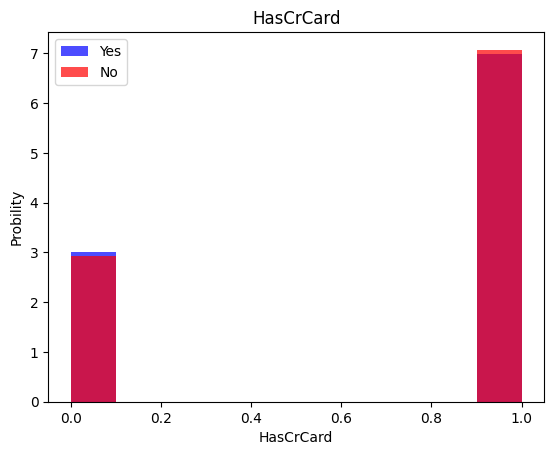

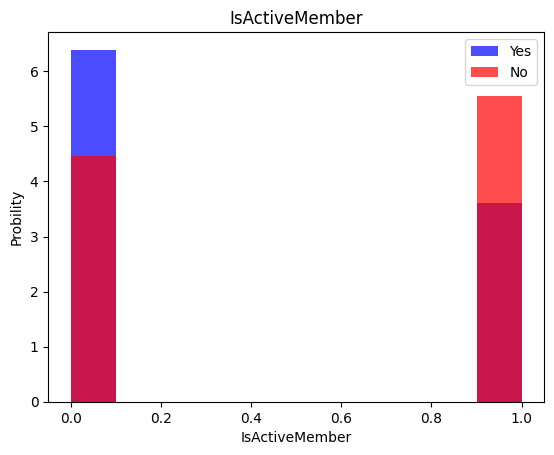

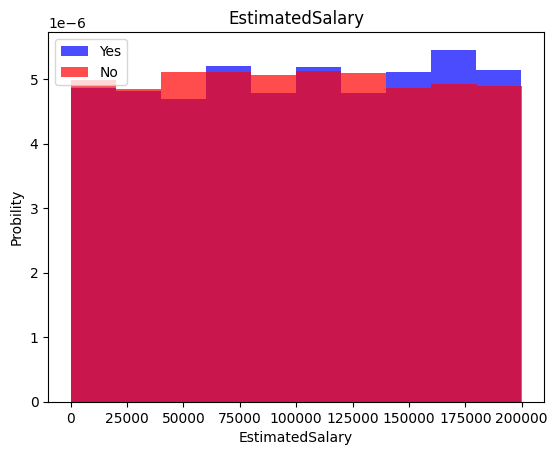

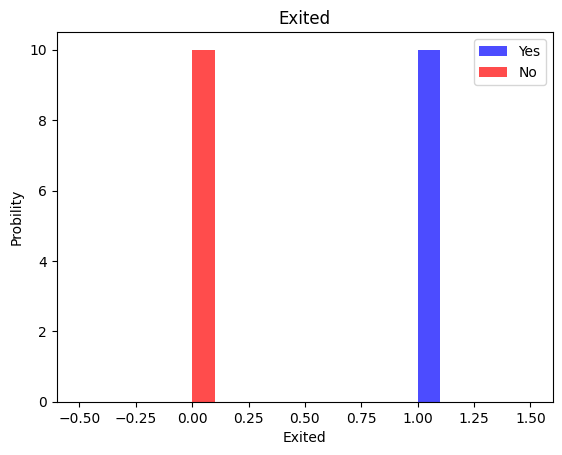

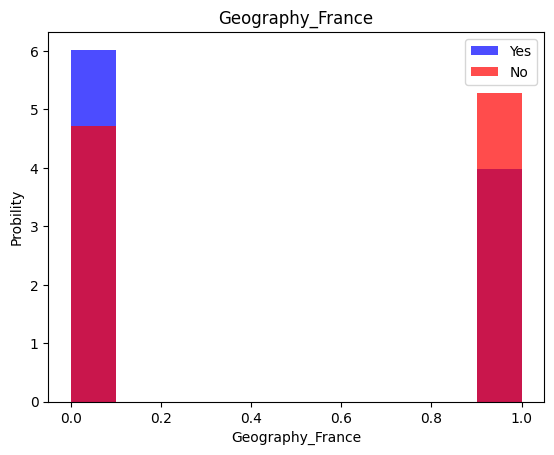

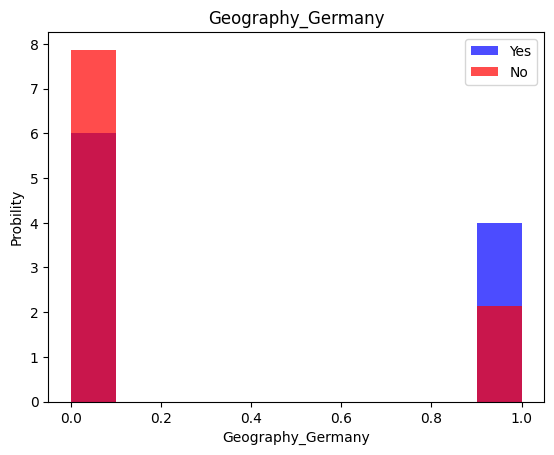

In [169]:
for label in df.columns[:-1]:
  plt.hist(df[df["Exited"]==1][label], color='blue', label='Yes', alpha = 0.7, density=True)
  plt.hist(df[df["Exited"]==0][label], color='red', label='No', alpha = 0.7, density=True)
  plt.title(label)
  plt.ylabel("Probility")
  plt.xlabel(label)
  plt.legend()
  plt.show()

In [170]:
count_males = ((df['Gender'] == 0) & (df['Exited'] == 0)).sum()
print(count_males)


4559


In [171]:
count_males = ((df['Gender'] == 1) & (df['Exited'] == 0)).sum()
print(count_males)

3404


In [172]:

counts = pd.crosstab(df['Gender'], df['Exited'])
print(counts)

Exited     0     1
Gender            
0       4559   898
1       3404  1139


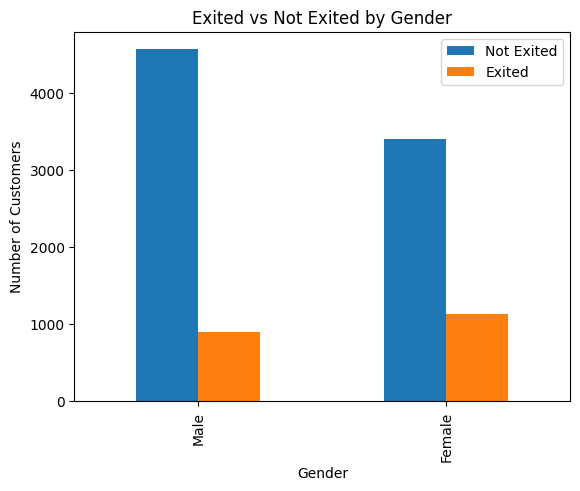

In [173]:

counts.index = ['Male', 'Female']
counts.columns = ['Not Exited', 'Exited']

counts.plot(kind='bar')

plt.title('Exited vs Not Exited by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

In [174]:
males_higher_mean_exit = len(df[
    (df['EstimatedSalary'] > df['EstimatedSalary'].mean()) &
    (df['Gender'] == 0) &
    (df['Exited'] == 1)
])

females_higher_mean_exit = len(df[
    (df['EstimatedSalary'] > df['EstimatedSalary'].mean()) &
    (df['Gender'] == 1) &
    (df['Exited'] == 1)
])

males_higher_mean_not_exit = len(df[
    (df['EstimatedSalary'] > df['EstimatedSalary'].mean()) &
    (df['Gender'] == 0) &
    (df['Exited'] == 0)
])

females_higher_mean_not_exit = len(df[
    (df['EstimatedSalary'] > df['EstimatedSalary'].mean()) &
    (df['Gender'] == 1) &
    (df['Exited'] == 0)
])

In [175]:
# labels = ['Male', 'Female']

# exited = [males_higher_mean_exit, females_higher_mean_exit]
# not_exited = [males_higher_mean_not_exit, females_higher_mean_not_exit]

# x = np.arange(len(labels))
# width = 0.35

# plt.bar(x - width/4, exited, width, label='Exited')
# plt.bar(x + width/4, not_exited, width, label='Not Exited')

# plt.xticks(x, labels)
# plt.xlabel('Gender')
# plt.ylabel('Number of Customers')
# plt.title('Customers with Salary Above Average who exited')
# plt.legend()

# plt.show()

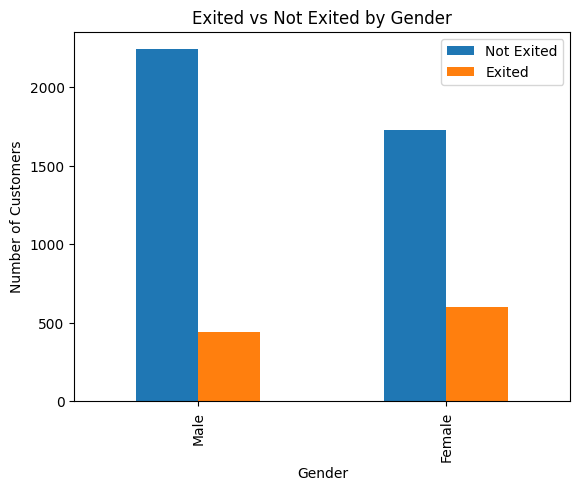

In [176]:
gender_leaving_counts = pd.crosstab(
    df[df['EstimatedSalary'] > df['EstimatedSalary'].mean()]['Gender'],
    df[df['EstimatedSalary'] > df['EstimatedSalary'].mean()]['Exited']
)

gender_leaving_counts.index = ['Male', 'Female']
gender_leaving_counts.columns = ['Not Exited', 'Exited']

gender_leaving_counts.plot(kind='bar')

plt.title('Exited vs Not Exited by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

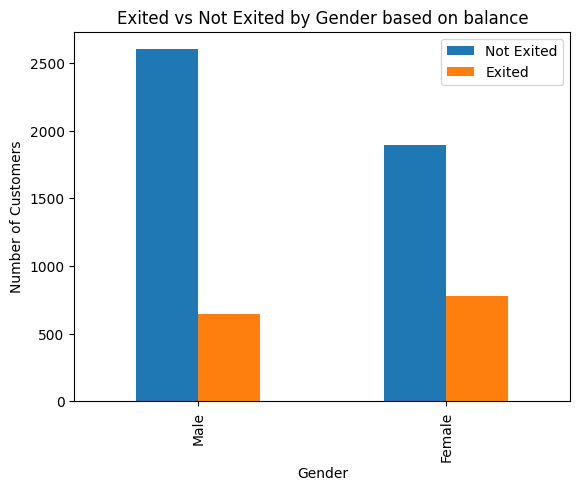

In [177]:
gender_leaving_counts = pd.crosstab(
    df[df['Balance'] > df['Balance'].mean()]['Gender'],
    df[df['Balance'] > df['Balance'].mean()]['Exited']
)

gender_leaving_counts.index = ['Male', 'Female']
gender_leaving_counts.columns = ['Not Exited', 'Exited']

gender_leaving_counts.plot(kind='bar')

plt.title('Exited vs Not Exited by Gender based on balance')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

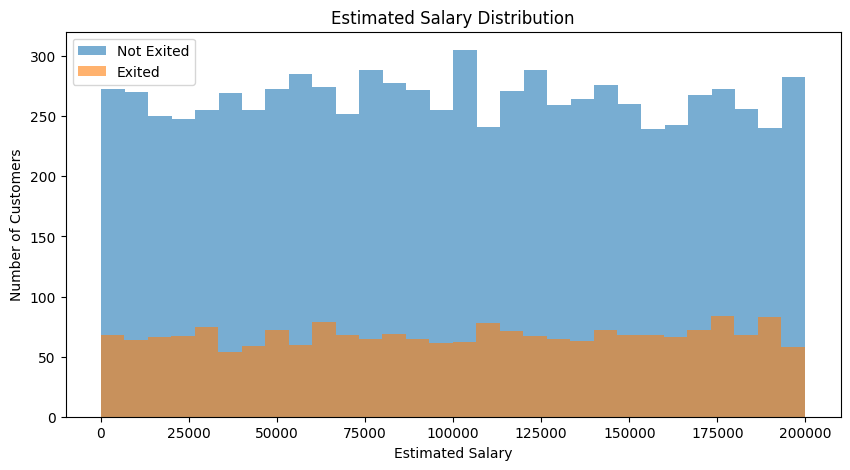

In [178]:

plt.figure(figsize=(10,5))

plt.hist(df[df['Exited']==0]['EstimatedSalary'],
         bins=30,
         alpha=0.6,
         label='Not Exited')

plt.hist(df[df['Exited']==1]['EstimatedSalary'],
         bins=30,
         alpha=0.6,
         label='Exited')

plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")
plt.title("Estimated Salary Distribution")
plt.legend()
plt.show()


### Predictions ML Part


Test, Train, validate Dataset

In [179]:
# train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

#Newer version:
df = df.sample(frac=1, random_state=42)

train = df.iloc[:int(0.6 * len(df))]
valid = df.iloc[int(0.6 * len(df)):int(0.8 * len(df))]
test = df.iloc[int(0.8 * len(df)):]

In [180]:
len(train[train['Exited']==1])


1230

In [181]:
len(train[train['Exited']==0])


4770

Using overSampler

In [182]:
def scale_dataset(dataframe, scaler=None, oversample=False):
  X = dataframe.drop('Exited', axis=1).values
  y = dataframe['Exited'].values

  if scaler is None:
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
  else:
    X = scaler.transform(X)

  if oversample:
    ros = RandomOverSampler()
    X, y = ros.fit_resample(X, y)

  data = np.hstack((X, np.reshape(y, (-1,1))))
  return data, X, y, scaler



In [183]:
train, X_train, y_train, scaler = scale_dataset(train, oversample=True)
valid, X_valid, y_valid, _ = scale_dataset(valid, scaler=scaler, oversample=False)
test, X_test, y_test, _ = scale_dataset(test, scaler=scaler, oversample=False)

In [184]:
sum(y_train==1)

np.int64(4770)

In [185]:
sum(y_train==0)

np.int64(4770)

In [186]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [187]:
y_pred = knn_model.predict(X_test)

In [188]:
y_pred

array([1, 1, 1, ..., 0, 0, 1])

In [189]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1590
           1       0.41      0.67      0.51       410

    accuracy                           0.73      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.73      0.75      2000



In [190]:
accuracy = (y_pred == y_test).mean()
accuracy

np.float64(0.7325)

## Testing the performance of Naive Bayes

In [191]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [192]:
y_pred = nb_model.predict(X_test)

In [193]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1590
           1       0.41      0.65      0.50       410

    accuracy                           0.74      2000
   macro avg       0.65      0.70      0.66      2000
weighted avg       0.79      0.74      0.76      2000



## Testing Logistic Regression

In [194]:
lg_model = LogisticRegression()
lg_model= lg_model.fit(X_train, y_train)

In [195]:
y_pred = lg_model.predict(X_test)

In [196]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.73      0.89      0.80      1298
           1       0.66      0.39      0.49       702

    accuracy                           0.71      2000
   macro avg       0.69      0.64      0.65      2000
weighted avg       0.71      0.71      0.69      2000




## Testing NN

In [197]:
normalizer = tf.keras.layers.Normalization()

normalizer.adapt(X_train)

nn_model = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1,activation='sigmoid'),
])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(0.01),loss='binary_crossentropy', metrics=['accuracy'])


In [198]:
history = nn_model.fit(X_train, y_train, epochs=100, verbose=1,batch_size = 32, validation_split=0.2)

Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6934 - loss: 0.5922 - val_accuracy: 0.5073 - val_loss: 0.8046
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7318 - loss: 0.5390 - val_accuracy: 0.5881 - val_loss: 0.6856
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7372 - loss: 0.5233 - val_accuracy: 0.5529 - val_loss: 0.6358
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7490 - loss: 0.5197 - val_accuracy: 0.6205 - val_loss: 0.6008
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7518 - loss: 0.5103 - val_accuracy: 0.5812 - val_loss: 0.6088
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7604 - loss: 0.5096 - val_accuracy: 0.5440 - val_loss: 0.6759
Epoch 7/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7621 - loss: 0.4983 - val_accuracy: 0.5372 - val_loss: 0.7064
Epoch 8/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7623 - loss: 0.4996 - val_accu

In [199]:
def plot_history(history):
    fig, (ax1, ax2)= plt.subplots(1,2, figsize=(10,4))
    ax1.plot(history.history['loss'], label='loss')
    ax1.plot(history.history['val_loss'], label='val_loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary crossentropy')
    ax1.legend()
    ax1.grid(True)


    ax2.plot(history.history['accuracy'], label='accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.show()

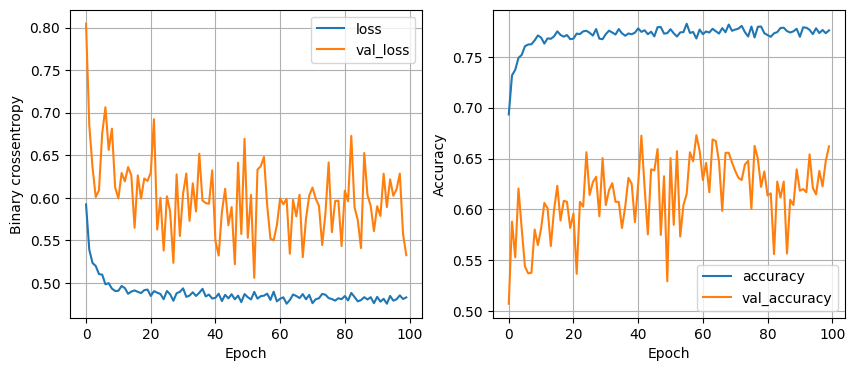

In [200]:
plot_history(history)

In [201]:
y_pred = nn_model.predict(X_test)
y_pred = (y_pred>0.5).astype(int).reshape(-1,)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [202]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1590
           1       0.57      0.58      0.58       410

    accuracy                           0.83      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.83      0.83      0.83      2000



Decision Trees

In [203]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [204]:
y_pred = dt.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1590
           1       0.51      0.46      0.48       410

    accuracy                           0.80      2000
   macro avg       0.69      0.67      0.68      2000
weighted avg       0.79      0.80      0.79      2000



In [205]:

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      1590
           1       0.67      0.51      0.58       410

    accuracy                           0.85      2000
   macro avg       0.77      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000

